# Levee Detection - Training Notebook

Train a deep learning model for levee detection from Copernicus DSM
and auxiliary channels. Stratified evaluation by catchment size (S/M/L).

**Author:** Jakub Zapletal  
**Date:** 2026-04-13  
**Version:** 0.1

In [40]:
import warnings

In [41]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import random

import threading
import queue

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import time


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PATCHES_DIR_PL  = Path(r"D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\geomorphological_ML\patches_v01_PL\patches")
PATCHES_DIR_NL  = Path(r"D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\geomorphological_ML\patches_v01_NL\patches")
METADATA_CSV_PL = Path(r"D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\geomorphological_ML\patches_v01_PL\patches_metadata.csv")
METADATA_CSV_NL = Path(r"D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\geomorphological_ML\patches_v01_NL\patches_metadata.csv")

OUTPUT_DIR = Path(r"D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\geomorphological_ML\training_v02_deeplabv3plus")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Hardware
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# On Windows, DataLoader workers use 'spawn' which causes massive overhead
# inside a Jupyter notebook. Use 0 (main-process loading) to avoid this.
NUM_WORKERS = 0   # Windows + Jupyter + CUDA deadlocks with spawned workers; use 0


# ------------------------------------------------------------
# Channels
# ------------------------------------------------------------
INPUT_CHANNELS = ["dsm", "tpi_r5", "tpi_r10", "tpi_r15", "canopy_height", "canopy_height_sd"]
LABEL_CHANNEL  = "label"
N_INPUT_CHANNELS = len(INPUT_CHANNELS)


# ------------------------------------------------------------
# Train/val/test split
# ------------------------------------------------------------
SPLIT_BY = "source_idx"     # group by original levee
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15


# ------------------------------------------------------------
# Training hyperparameters
# ------------------------------------------------------------
BATCH_SIZE      = 16
N_EPOCHS        = 100
LR              = 1e-4
WEIGHT_DECAY    = 1e-3   # was 1e-4 - stronger L2 regularization to fight overconfidence
GRAD_CLIP       = 1.0
MIXED_PRECISION = True


# ------------------------------------------------------------
# Loss function
# ------------------------------------------------------------
LOSS_DICE_WEIGHT   = 0.5     # alpha in α·Dice + (1-α)·clDice
CLDICE_ITER        = 5       # soft skeleton iterations


# ------------------------------------------------------------
# Architecture
# ------------------------------------------------------------
# Choose one: "resnet_unet" | "segformer" | "deeplabv3plus"
# Each architecture is meant to run as a separate experiment with its own
# OUTPUT_DIR (set above). Predictions from the three runs are then stacked
# in a follow-up notebook.
ARCHITECTURE = "deeplabv3plus"

# Backbones per architecture
RESNET_BACKBONE     = "resnet34"   # for resnet_unet
SEGFORMER_BACKBONE  = "mit_b2"     # for segformer
DEEPLAB_BACKBONE    = "resnet50"   # for deeplabv3plus (larger encoder)

# Pretrained weights
# - ResNet encoders use torchvision weights (no HuggingFace dependency)
# - mit_b* encoders fetch imagenet weights from HuggingFace Hub on first run
RESNET_ENCODER_WEIGHTS    = "imagenet"
DEEPLAB_ENCODER_WEIGHTS   = "imagenet"
SEGFORMER_ENCODER_WEIGHTS = "imagenet"  # was None - now use HF weights for fair comparison


# ------------------------------------------------------------
# Augmentation
# ------------------------------------------------------------
USE_FLIP_H = True

USE_FLIP_V = True
USE_ROT_90 = True


print(f"Device: {DEVICE}")
print(f"Input channels ({N_INPUT_CHANNELS}): {INPUT_CHANNELS}")
print(f"Architecture: {ARCHITECTURE}")


Device: cuda
Input channels (6): ['dsm', 'tpi_r5', 'tpi_r10', 'tpi_r15', 'canopy_height', 'canopy_height_sd']
Architecture: deeplabv3plus


## 2. Dataset

`LeveeDataset` wraps `.npz` patch files and handles three responsibilities:

- **Loading** — resolves the correct patch directory by region and reads all channels from the `.npz` file.
- **Normalization** — DSM is locally centred (subtract per-patch median); all other channels are z-scored using pre-computed dataset statistics.
- **Augmentation** — geometry-only transforms (90° rotations, horizontal/vertical flips) applied consistently to both image and label to preserve linear structures.

In [42]:
class LeveeDataset(Dataset):
    """
    Loads .npz patches and applies normalization + augmentation.

    Each sample is a dict with:
      - "image":    tensor of shape (C, H, W), float32
      - "label":    tensor of shape (1, H, W), float32
      - "patch_id": str
      - "category": str (S/M/L)
    """

    def __init__(
        self,
        metadata_df,
        patches_root_dirs,
        input_channels,
        norm_stats,
        augment=False,
    ):
        self.metadata = metadata_df.reset_index(drop=True)
        self.patches_root_dirs = patches_root_dirs   # dict {region: Path}
        self.input_channels = input_channels
        self.norm_stats = norm_stats                 # dict per channel: {"mean": ..., "std": ...}
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def _load_npz(self, row):
        """Locate and load the .npz file based on region prefix in patch_id."""
        region = row["region"]
        npz_path = self.patches_root_dirs[region] / f"{row['patch_id']}.npz"
        return dict(np.load(npz_path))

    def _normalize(self, channels):
        """
        Per-patch normalization for DSM (subtract median).
        Per-channel z-score for everything else.
        """
        out = {}
        for ch_name in self.input_channels:
            arr = channels[ch_name].astype(np.float32)

            # Replace NaN with 0 (rare, only at DSM raster edges)
            arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

            if ch_name == "dsm":
                arr = arr - np.median(arr)
            else:
                stats = self.norm_stats[ch_name]
                arr = (arr - stats["mean"]) / (stats["std"] + 1e-6)

            out[ch_name] = arr
        return out

    def _augment(self, image, label):
        """
        Apply geometry-only augmentations: 90° rotations, H/V flips.
        All transformations preserve linear structures.
        """
        # Random 90° rotation: 0, 90, 180, 270 degrees
        if USE_ROT_90:
            k = np.random.randint(0, 4)
            if k > 0:
                image = np.rot90(image, k=k, axes=(1, 2)).copy()
                label = np.rot90(label, k=k, axes=(1, 2)).copy()

        # Random horizontal flip
        if USE_FLIP_H and np.random.rand() < 0.5:
            image = np.flip(image, axis=2).copy()
            label = np.flip(label, axis=2).copy()

        # Random vertical flip
        if USE_FLIP_V and np.random.rand() < 0.5:
            image = np.flip(image, axis=1).copy()
            label = np.flip(label, axis=1).copy()

        return image, label

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        channels = self._load_npz(row)

        # Normalize each input channel
        channels_norm = self._normalize(channels)

        # Stack into (C, H, W)
        image = np.stack([channels_norm[c] for c in self.input_channels], axis=0)

        # Label: (1, H, W)
        label = channels[LABEL_CHANNEL].astype(np.float32)[np.newaxis, ...]

        # Augment
        if self.augment:
            image, label = self._augment(image, label)

        return {
            "image":    torch.from_numpy(image),
            "label":    torch.from_numpy(label),
            "patch_id": row["patch_id"],
            "category": row["category"],
        }

## 3. Data Split

Metadata from both regions (PL, NL) is merged and split into train / val / test subsets.
Splitting is done at the **source levee level** (`source_idx_global`) rather than at the patch level,
so all patches derived from the same levee end up in the same subset — preventing data leakage.

Negative patches (background samples) are assigned to the same group as their parent positive patch
before the split is performed. The resulting split ratio is approximately 70 / 15 / 15.

In [43]:
# Load metadata for both regions
df_pl = pd.read_csv(METADATA_CSV_PL)
df_pl["region"] = "PL"
df_nl = pd.read_csv(METADATA_CSV_NL)
df_nl["region"] = "NL"

df = pd.concat([df_pl, df_nl], ignore_index=True)

# Create globally unique source_idx (region prefix prevents collisions)
# All patches (positive and negative) share the same comid as their parent levee
df["comid"] = df["comid"].astype(int)
df["source_idx_global"] = df["region"] + "_" + df["comid"].astype(str)

# Random split of unique source_idx values
unique_sources = df["source_idx_global"].unique()
rng = np.random.default_rng(SEED)
rng.shuffle(unique_sources)

n_total = len(unique_sources)
n_train = int(n_total * TRAIN_FRAC)
n_val   = int(n_total * VAL_FRAC)

train_sources = set(unique_sources[:n_train])
val_sources   = set(unique_sources[n_train:n_train + n_val])
test_sources  = set(unique_sources[n_train + n_val:])

df["split"] = df["source_idx_global"].apply(
    lambda s: "train" if s in train_sources
    else "val" if s in val_sources
    else "test"
)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "val"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Total patches: {len(df)}")
print(f"  Train: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")
print()
print("Patches per category × split:")
print(df.groupby(["split", "category", "patch_type"]).size().unstack(fill_value=0))

df.to_csv(OUTPUT_DIR / "metadata_with_split.csv", index=False)


Total patches: 89810
  Train: 62008 (69.0%)
  Val:   14214 (15.8%)
  Test:  13588 (15.1%)

Patches per category × split:
patch_type      negative  positive
split category                    
test  L              970       970
      M             1357      1357
      S             4467      4467
train L             5696      5696
      M             6178      6178
      S            19130     19130
val   L             1338      1338
      M             1278      1278
      S             4491      4491


In [44]:
df_test["patch_id"].head()

0    pos_0000271
1    pos_0000272
2    pos_0000273
3    pos_0000274
4    pos_0000275
Name: patch_id, dtype: str

In [45]:
df_test["patch_id"].head()

0    pos_0000271
1    pos_0000272
2    pos_0000273
3    pos_0000274
4    pos_0000275
Name: patch_id, dtype: str

## 4. Normalization Statistics

Per-channel mean and standard deviation are computed **from the training set only** to avoid leakage.
DSM is excluded — it is centred per-patch at runtime by subtracting the patch median.
All other channels are z-scored using these statistics during `LeveeDataset._normalize()`.

A single streaming pass over the training patches is used (sum / sum-of-squares accumulation),
so the full dataset never needs to fit in memory. Results are saved to `norm_stats.json`
for reproducibility and reuse during inference.

In [46]:

# Channels that need per-channel z-score (DSM is normalized per-patch in dataset)
CHANNELS_TO_NORMALIZE = [c for c in INPUT_CHANNELS if c != "dsm"]

# Welford's online algorithm — accumulates mean and std without loading
# all patches into memory at once
sums   = {c: 0.0 for c in CHANNELS_TO_NORMALIZE}
sq_sums = {c: 0.0 for c in CHANNELS_TO_NORMALIZE}
counts = {c: 0   for c in CHANNELS_TO_NORMALIZE}

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Computing norm stats"):
    npz_path = {"PL": PATCHES_DIR_PL, "NL": PATCHES_DIR_NL}[row["region"]] / f"{row['patch_id']}.npz"
    channels = dict(np.load(npz_path))

    for c in CHANNELS_TO_NORMALIZE:
        arr = np.nan_to_num(channels[c].astype(np.float64))
        sums[c]    += arr.sum()
        sq_sums[c] += (arr ** 2).sum()
        counts[c]  += arr.size

norm_stats = {}
for c in CHANNELS_TO_NORMALIZE:
    mean = sums[c] / counts[c]
    var  = sq_sums[c] / counts[c] - mean ** 2
    std  = np.sqrt(max(var, 1e-12))
    norm_stats[c] = {"mean": float(mean), "std": float(std)}

# DSM is per-patch normalized, but we still record a sentinel for clarity
norm_stats["dsm"] = {"mean": 0.0, "std": 1.0}

print("Normalization stats:")
for c, s in norm_stats.items():
    print(f"  {c:20s}  mean={s['mean']:8.3f}  std={s['std']:8.3f}")

with open(OUTPUT_DIR / "norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)

Computing norm stats: 100%|██████████| 62008/62008 [08:41<00:00, 118.97it/s]

Normalization stats:
  tpi_r5                mean=  -0.000  std=   1.190
  tpi_r10               mean=  -0.002  std=   2.166
  tpi_r15               mean=  -0.004  std=   2.858
  canopy_height         mean=   9.300  std=   8.641
  canopy_height_sd      mean=   4.571  std=   2.866
  dsm                   mean=   0.000  std=   1.000


## 5. Model Definition

Two architectures are supported:

- **SegFormer** (`mit_b2` encoder) — initialised with **random weights** (`encoder_weights=None`).
  `mit_b*` encoders download ImageNet weights from HuggingFace Hub, which this project avoids.
  `in_channels` is set to `N_INPUT_CHANNELS` directly, so no first-conv adaptation is needed.

- **ResNet-UNet** (`resnet34` encoder) — initialised with **ImageNet-pretrained weights** fetched
  from torchvision (PyTorch CDN, no HuggingFace dependency) and then adapted to accept the
  6-channel input via `adapt_first_conv_for_extra_channels()`, which tiles the pretrained
  3-channel weights and rescales them to preserve activation magnitude.

In [47]:
def adapt_first_conv_for_extra_channels(model, n_input_channels):
    """
    Replicate pretrained 3-channel first-conv weights to support N input channels.
    Works for any encoder where the first conv is exposed under a known attribute
    (ResNet: encoder.conv1).
    """
    encoder = model.encoder

    if hasattr(encoder, "conv1"):                     # ResNet family
        first_conv = encoder.conv1
        attr_name = "conv1"
    else:
        raise RuntimeError("Unknown encoder structure - cannot find first conv")

    old_weight = first_conv.weight.data            # (out_ch, 3, k, k)
    out_ch, _, kh, kw = old_weight.shape

    new_weight = old_weight.repeat(1, (n_input_channels // 3) + 1, 1, 1)
    new_weight = new_weight[:, :n_input_channels, :, :]
    new_weight = new_weight / (n_input_channels / 3)   # rescale to keep activation magnitude

    new_conv = nn.Conv2d(
        n_input_channels,
        out_ch,
        kernel_size=(kh, kw),
        stride=first_conv.stride,
        padding=first_conv.padding,
        bias=first_conv.bias is not None,
    )
    new_conv.weight.data = new_weight
    if first_conv.bias is not None:
        new_conv.bias.data = first_conv.bias.data.clone()

    setattr(encoder, attr_name, new_conv)
    return model


def adapt_first_conv_segformer(model, n_input_channels):
    """
    SegFormer (mit_b*) uses a patch_embed1.proj first conv (not conv1).
    Same replication-with-rescaling trick, different attribute path.
    """
    encoder = model.encoder
    # mit_b* encoders expose stages as patch_embed1, patch_embed2, ...
    # The very first projection is patch_embed1.proj
    if not hasattr(encoder, "patch_embed1"):
        raise RuntimeError("SegFormer encoder does not have patch_embed1 - check smp version")

    first_conv = encoder.patch_embed1.proj
    old_weight = first_conv.weight.data            # (out_ch, 3, k, k)
    out_ch, _, kh, kw = old_weight.shape

    new_weight = old_weight.repeat(1, (n_input_channels // 3) + 1, 1, 1)
    new_weight = new_weight[:, :n_input_channels, :, :]
    new_weight = new_weight / (n_input_channels / 3)

    new_conv = nn.Conv2d(
        n_input_channels,
        out_ch,
        kernel_size=(kh, kw),
        stride=first_conv.stride,
        padding=first_conv.padding,
        bias=first_conv.bias is not None,
    )
    new_conv.weight.data = new_weight
    if first_conv.bias is not None:
        new_conv.bias.data = first_conv.bias.data.clone()

    encoder.patch_embed1.proj = new_conv
    return model


# ----------------------------------------------------------
# Build model based on ARCHITECTURE config
# ----------------------------------------------------------
if ARCHITECTURE == "resnet_unet":
    # CNN encoder + U-Net decoder with skip connections
    model = smp.Unet(
        encoder_name=RESNET_BACKBONE,
        encoder_weights=RESNET_ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None,
    )
    model = adapt_first_conv_for_extra_channels(model, N_INPUT_CHANNELS)

elif ARCHITECTURE == "segformer":
    # Transformer encoder (MIT) + lightweight MLP decoder
    model = smp.Segformer(
        encoder_name=SEGFORMER_BACKBONE,
        encoder_weights=SEGFORMER_ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None,
    )
    model = adapt_first_conv_segformer(model, N_INPUT_CHANNELS)

elif ARCHITECTURE == "deeplabv3plus":
    # CNN encoder + DeepLabV3+ decoder with ASPP (atrous spatial pyramid pooling)
    # Different decoder design from U-Net: dilated convs at multiple rates
    # capture multi-scale context in a single forward pass.
    model = smp.DeepLabV3Plus(
        encoder_name=DEEPLAB_BACKBONE,
        encoder_weights=DEEPLAB_ENCODER_WEIGHTS,
        in_channels=3,
        classes=1,
        activation=None,
    )
    model = adapt_first_conv_for_extra_channels(model, N_INPUT_CHANNELS)

else:
    raise ValueError(f"Unknown architecture: {ARCHITECTURE}")


# ----------------------------------------------------------
# Decoder dropout (regularization to fight overconfidence)
# ----------------------------------------------------------
# We wrap the second conv in each decoder block with Dropout2d so dropout
# is applied after the second Conv-BN-ReLU of every decoder stage.
# Encoder stays untouched (preserves pretrained weights).
#
# Each architecture has a different decoder structure:
#   - U-Net:        decoder.blocks (5 DecoderBlock instances, each with conv1+conv2)
#   - DeepLabV3+:   decoder.block1 (ASPP) + decoder.block2 (final 3x3 conv) - simpler structure
#   - SegFormer:    decoder is a lightweight MLP head, no real "blocks" to dropout
DECODER_DROPOUT_P = 0.1

if ARCHITECTURE == "resnet_unet":
    for block in model.decoder.blocks:
        block.conv2 = nn.Sequential(block.conv2, nn.Dropout2d(p=DECODER_DROPOUT_P))
    print(f"Decoder dropout: {DECODER_DROPOUT_P} (applied to {len(model.decoder.blocks)} U-Net blocks)")

elif ARCHITECTURE == "deeplabv3plus":
    # smp.DeepLabV3Plus exposes decoder.block1 (ASPP-related) and decoder.block2 (final 3x3 conv).
    # Wrap block2 with dropout - it's the final feature-refinement conv before the seg head.
    if hasattr(model.decoder, "block2"):
        model.decoder.block2 = nn.Sequential(model.decoder.block2, nn.Dropout2d(p=DECODER_DROPOUT_P))
        print(f"Decoder dropout: {DECODER_DROPOUT_P} (applied to DeepLabV3+ block2)")
    else:
        print("[WARN] DeepLabV3+ decoder.block2 not found - skipping dropout. Check smp version.")

elif ARCHITECTURE == "segformer":
    # SegFormer decoder is a lightweight MLP head; native dropout is unusual here.
    # Skipping dropout for SegFormer - regularization comes from weight_decay only.
    print(f"[INFO] No decoder dropout for SegFormer (lightweight MLP head)")


model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture: {ARCHITECTURE}")
print(f"Trainable parameters: {n_params:,}")


Decoder dropout: 0.1 (applied to DeepLabV3+ block2)
Architecture: deeplabv3plus
Trainable parameters: 26,686,993


## 6. Loss Function

Training uses a hybrid objective that combines region overlap and topology preservation:

- **Dice loss** measures pixel-wise overlap between predicted and target masks.
- **clDice loss** compares soft morphological skeletons to better preserve thin, connected levee structures.
- **Combined loss** blends both terms as `LOSS_DICE_WEIGHT * Dice + (1 - LOSS_DICE_WEIGHT) * clDice`.

The soft-skeleton operator is implemented with differentiable erosion/dilation (max-pooling based), so topology-aware supervision remains fully compatible with backpropagation.

In [48]:
def soft_skeleton(x, n_iter):
    def soft_erode(img):
        p1 = -F.max_pool2d(-img, (3, 1), stride=1, padding=(1, 0))
        p2 = -F.max_pool2d(-img, (1, 3), stride=1, padding=(0, 1))
        return torch.min(p1, p2)

    def soft_dilate(img):
        return F.max_pool2d(img, (3, 3), stride=1, padding=1)

    def soft_open(img):
        return soft_dilate(soft_erode(img))

    skel = F.relu(x - soft_open(x))
    img = x
    for _ in range(n_iter):
        img = soft_erode(img)
        skel = skel + F.relu(img - soft_open(img)) * (1.0 - skel)
    return skel


def dice_loss(pred, target, eps=1e-6):
    """Standard soft Dice loss on sigmoid probabilities."""
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def cldice_loss(pred, target, n_iter, eps=1e-6):
    """
    Centerline Dice loss — measures overlap between morphological
    skeletons of prediction and target.
    """
    pred = torch.sigmoid(pred)

    skel_pred = soft_skeleton(pred, n_iter)
    skel_target = soft_skeleton(target, n_iter)

    # Topology precision: skel_pred ∩ target / skel_pred
    tprec = (skel_pred * target).sum(dim=(1, 2, 3)) + eps
    tprec = tprec / (skel_pred.sum(dim=(1, 2, 3)) + eps)

    # Topology recall: pred ∩ skel_target / skel_target
    trec = (pred * skel_target).sum(dim=(1, 2, 3)) + eps
    trec = trec / (skel_target.sum(dim=(1, 2, 3)) + eps)

    cldice = 2 * tprec * trec / (tprec + trec)
    return 1 - cldice.mean()

BCE_POS_WEIGHT = 20.0


def combined_loss(pred, target):
    """
    BCE (with positive-pixel weight) + α·Dice + (1-α)·clDice.

    BCE with pos_weight directly counters the all-zeros trivial minimum that
    pure Dice/clDice losses fall into on highly class-imbalanced data.
    """
    pw = torch.tensor(BCE_POS_WEIGHT, device=pred.device, dtype=pred.dtype)
    l_bce    = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pw)
    l_dice   = dice_loss(pred, target)
    l_cldice = cldice_loss(pred, target, n_iter=CLDICE_ITER)
    return l_bce + LOSS_DICE_WEIGHT * l_dice + (1 - LOSS_DICE_WEIGHT) * l_cldice


## 7. Training Loop

This section builds train and validation datasets, wraps them in dataloaders, and runs the epoch-based optimization loop.

- Training uses AdamW, cosine annealing, mixed precision, and gradient clipping.
- Validation tracks both loss and hard Dice score for monitoring.
- The best checkpoint (lowest validation loss) and full training history are saved to disk for later evaluation.

In [49]:

# Dataset and dataloader setup
patches_root_dirs = {"PL": PATCHES_DIR_PL, "NL": PATCHES_DIR_NL}

train_ds = LeveeDataset(df_train, patches_root_dirs, INPUT_CHANNELS, norm_stats, augment=True)
val_ds   = LeveeDataset(df_val,   patches_root_dirs, INPUT_CHANNELS, norm_stats, augment=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)


class PrefetchLoader:
    """
    Wraps a DataLoader and prefetches the next batch in a background thread.
    Overlaps disk I/O with GPU compute, boosting utilisation from ~10% to ~60-80%
    without any multiprocessing (avoids Windows/Jupyter/CUDA spawn deadlocks).
    """
    def __init__(self, loader, queue_size=2):
        self.loader = loader
        self.queue_size = queue_size

    def __iter__(self):
        q = queue.Queue(maxsize=self.queue_size)

        def _worker():
            try:
                for batch in self.loader:
                    q.put(batch)
            finally:
                q.put(None)  # sentinel

        t = threading.Thread(target=_worker, daemon=True)
        t.start()
        while True:
            item = q.get()
            if item is None:
                break
            yield item

    def __len__(self):
        return len(self.loader)


train_loader = PrefetchLoader(train_loader)
val_loader   = PrefetchLoader(val_loader)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR * 0.01)
scaler = torch.amp.GradScaler(device='cuda',enabled=MIXED_PRECISION)

# History
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "val_dice": [], "val_cldice": [], "val_score": [], "lr": [],
}
best_val_score = -float("inf")     # we MAXIMIZE this now (was: minimize val_loss)
checkpoint_path = OUTPUT_DIR / "best_model.pt"

# ------------------------------------------------------------
# Epoch loop
# ------------------------------------------------------------
for epoch in range(N_EPOCHS):

    # ---- Train ----
    model.train()
    train_loss_sum, n_train_batches = 0.0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [train]"):
        image = batch["image"].to(DEVICE, non_blocking=True)
        label = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=MIXED_PRECISION):
            pred = model(image)
            loss = combined_loss(pred, label)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item()
        n_train_batches += 1

    train_loss = train_loss_sum / n_train_batches

    # ---- Validation ----
    model.eval()
    val_loss_sum, val_dice_sum, val_cldice_sum, n_val_batches = 0.0, 0.0, 0.0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [val]"):
            image = batch["image"].to(DEVICE, non_blocking=True)
            label = batch["label"].to(DEVICE, non_blocking=True)

            with autocast(enabled=MIXED_PRECISION):
                pred = model(image)
                loss = combined_loss(pred, label)

            val_loss_sum += loss.item()

            pred_bin = (torch.sigmoid(pred) > 0.5).float()

            # Hard Dice
            inter = (pred_bin * label).sum(dim=(1, 2, 3))
            union = pred_bin.sum(dim=(1, 2, 3)) + label.sum(dim=(1, 2, 3))
            dice = (2 * inter + 1e-6) / (union + 1e-6)
            val_dice_sum += dice.mean().item()

            # Hard clDice (skeleton-based, on binarized prediction)
            skel_p = soft_skeleton(pred_bin, CLDICE_ITER)
            skel_l = soft_skeleton(label,    CLDICE_ITER)
            tprec = ((skel_p * label).sum(dim=(1, 2, 3)) + 1e-6) / (skel_p.sum(dim=(1, 2, 3)) + 1e-6)
            trec  = ((pred_bin * skel_l).sum(dim=(1, 2, 3)) + 1e-6) / (skel_l.sum(dim=(1, 2, 3)) + 1e-6)
            cldice = 2 * tprec * trec / (tprec + trec)
            val_cldice_sum += cldice.mean().item()

            n_val_batches += 1

    val_loss   = val_loss_sum   / n_val_batches
    val_dice   = val_dice_sum   / n_val_batches
    val_cldice = val_cldice_sum / n_val_batches
    val_score  = (val_dice + val_cldice) / 2     # combined selection criterion

    # Log before stepping scheduler so the recorded LR matches what was used this epoch
    current_lr = optimizer.param_groups[0]["lr"]
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_cldice"].append(val_cldice)
    history["val_score"].append(val_score)
    history["lr"].append(current_lr)

    scheduler.step()

    print(
        f"Epoch {epoch+1:3d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_dice={val_dice:.4f} | "
        f"val_cldice={val_cldice:.4f} | "
        f"val_score={val_score:.4f} | "
        f"lr={current_lr:.2e}"
    )

    # Save best by combined val_score (MAXIMIZE), not val_loss (was: MINIMIZE)
    if val_score > best_val_score:
        best_val_score = val_score
        torch.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":   val_loss,
            "val_dice":   val_dice,
            "val_cldice": val_cldice,
            "val_score":  val_score,
        }, checkpoint_path)

pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)


Epoch 1/100 [train]:   0%|          | 0/3875 [00:00<?, ?it/s]

Epoch 1/100 [val]: 100%|██████████| 889/889 [02:25<00:00,  6.10it/s]


Epoch   1 | train_loss=1.3414 | val_loss=1.2731 | val_dice=0.2675 | val_cldice=0.3259 | val_score=0.2967 | lr=1.00e-04


Epoch 2/100 [val]: 100%|██████████| 889/889 [02:21<00:00,  6.30it/s]


Epoch   2 | train_loss=1.2007 | val_loss=1.2293 | val_dice=0.2802 | val_cldice=0.3625 | val_score=0.3213 | lr=1.00e-04


...

Epoch  98 | train_loss=0.2344 | val_loss=3.6387 | val_dice=0.5684 | val_cldice=0.6690 | val_score=0.6187 | lr=1.22e-06


Epoch 99/100 [val]: 100%|██████████| 889/889 [02:35<00:00,  5.73it/s]


Epoch  99 | train_loss=0.2344 | val_loss=4.3828 | val_dice=0.5374 | val_cldice=0.6241 | val_score=0.5808 | lr=1.10e-06


Epoch 100/100 [val]: 100%|██████████| 889/889 [02:35<00:00,  5.70it/s]

Epoch 100 | train_loss=0.2342 | val_loss=3.9274 | val_dice=0.5602 | val_cldice=0.6569 | val_score=0.6085 | lr=1.02e-06


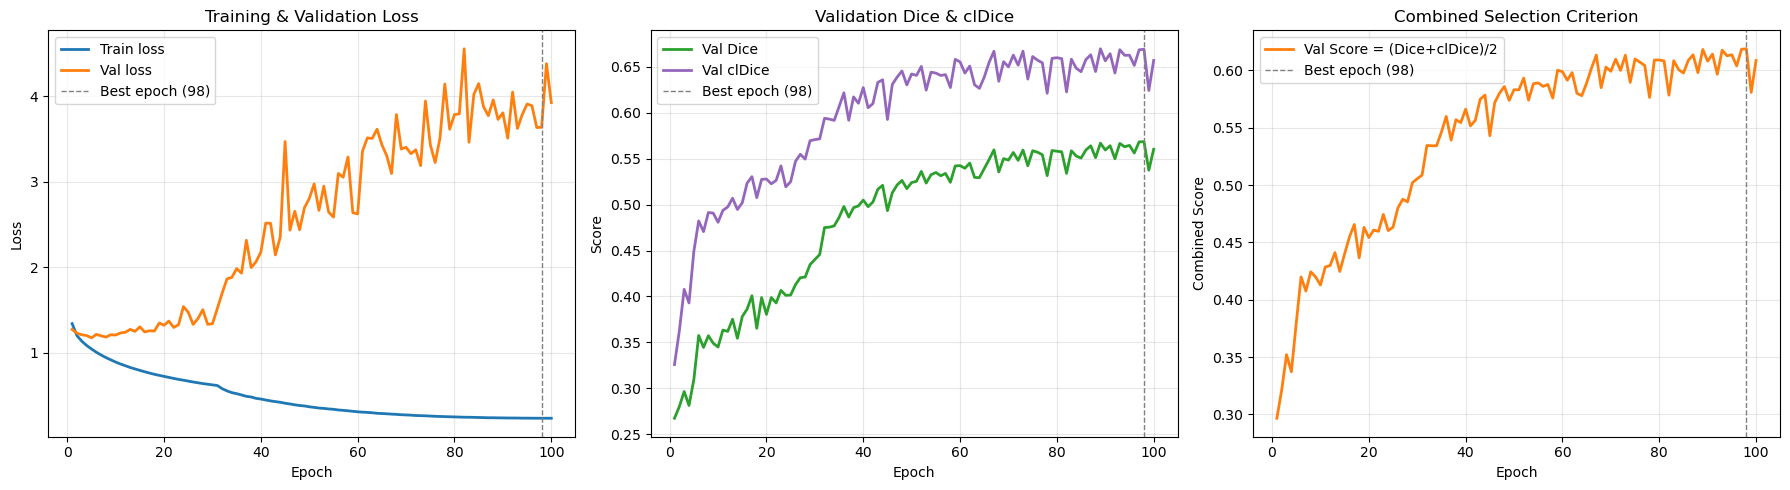

Best epoch: 98  |  val_score=0.6187  |  val_dice=0.5684  |  val_cldice=0.6690  |  val_loss=3.6387


In [50]:
# ---- Plot training / validation curves ----
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss", linewidth=2)
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   label="Val loss",   linewidth=2)
best_epoch = int(hist_df.loc[hist_df["val_score"].idxmax(), "epoch"])
axes[0].axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation Dice + clDice curves
axes[1].plot(hist_df["epoch"], hist_df["val_dice"],   color="tab:green",  linewidth=2, label="Val Dice")
axes[1].plot(hist_df["epoch"], hist_df["val_cldice"], color="tab:purple", linewidth=2, label="Val clDice")
axes[1].axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Dice & clDice")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Combined val_score (selection criterion)
axes[2].plot(hist_df["epoch"], hist_df["val_score"], color="tab:orange", linewidth=2, label="Val Score = (Dice+clDice)/2")
axes[2].axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Combined Score")
axes[2].set_title("Combined Selection Criterion")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

best_row = hist_df.loc[hist_df["val_score"].idxmax()]
print(
    f"Best epoch: {int(best_row['epoch'])}  |  "
    f"val_score={best_row['val_score']:.4f}  |  "
    f"val_dice={best_row['val_dice']:.4f}  |  "
    f"val_cldice={best_row['val_cldice']:.4f}  |  "
    f"val_loss={best_row['val_loss']:.4f}"
)


## 8. Evaluation by Category and Region

This section reloads the best validation checkpoint and evaluates it on the held-out test split:

- Metrics are computed per patch: Dice, IoU, clDice, and label-pixel count.
- Results are then aggregated by category and patch type, and separately by region and patch type.
- Overall mean and standard deviation are printed, and all detailed/aggregated tables are exported to CSV for analysis.

In [51]:
# Load best checkpoint
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")
print(f"  val_loss   = {checkpoint['val_loss']:.4f}")
print(f"  val_dice   = {checkpoint['val_dice']:.4f}")
print(f"  val_cldice = {checkpoint.get('val_cldice', float('nan')):.4f}")
print(f"  val_score  = {checkpoint.get('val_score',  float('nan')):.4f}")


# ----------------------------------------------------------
# Evaluation utility: runs inference, saves raw predictions,
# computes per-patch metrics. Used for both val and test.
# Predictions are saved as float16 .npz per patch so all 3
# models can later be combined in a stacking notebook.
# ----------------------------------------------------------
SAVE_PREDICTIONS = True   # set False if disk space is tight

def evaluate_split(df_split, split_name):
    """
    Evaluate model on a split, save per-patch predictions, return metrics df.

    Predictions are saved to:
        OUTPUT_DIR / "predictions_{split_name}" / "{patch_id}.npz"
    Each .npz contains:
        pred:  float16 array (256, 256) of sigmoid probabilities
    """
    pred_dir = OUTPUT_DIR / f"predictions_{split_name}"
    if SAVE_PREDICTIONS:
        pred_dir.mkdir(exist_ok=True)

    ds = LeveeDataset(df_split, patches_root_dirs, INPUT_CHANNELS, norm_stats, augment=False)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )

    records = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name} set"):
            image = batch["image"].to(DEVICE, non_blocking=True)
            label = batch["label"].to(DEVICE, non_blocking=True)

            with autocast(enabled=MIXED_PRECISION):
                pred = model(image)
                pred_prob = torch.sigmoid(pred)

            pred_bin = (pred_prob > 0.5).float()

            # Per-sample work: metrics + saving raw probabilities
            for i in range(image.size(0)):
                p = pred_bin[i:i+1]
                l = label[i:i+1]

                inter = (p * l).sum().item()
                p_sum = p.sum().item()
                l_sum = l.sum().item()

                dice = (2 * inter + 1e-6) / (p_sum + l_sum + 1e-6)
                iou  = (inter + 1e-6) / (p_sum + l_sum - inter + 1e-6)

                # clDice on binarized prediction (skeleton-based)
                skel_p = soft_skeleton(p, CLDICE_ITER)
                skel_l = soft_skeleton(l, CLDICE_ITER)
                tprec  = ((skel_p * l).sum() + 1e-6) / (skel_p.sum() + 1e-6)
                trec   = ((p * skel_l).sum() + 1e-6) / (skel_l.sum() + 1e-6)
                cldice = (2 * tprec * trec / (tprec + trec)).item()

                patch_id = batch["patch_id"][i]
                records.append({
                    "patch_id":   patch_id,
                    "category":   batch["category"][i],
                    "dice":       dice,
                    "iou":        iou,
                    "cldice":     cldice,
                    "n_label_px": int(l_sum),
                })

                # Save raw sigmoid probabilities (float16 to halve disk usage)
                if SAVE_PREDICTIONS:
                    pred_to_save = pred_prob[i, 0].cpu().numpy().astype(np.float16)
                    np.savez_compressed(
                        pred_dir / f"{patch_id}.npz",
                        pred=pred_to_save,
                    )

    df_results = pd.DataFrame(records)
    df_results = df_results.merge(
        df_split[["patch_id", "region", "patch_type"]],
        on="patch_id", how="left",
    )
    return df_results


# ----------------------------------------------------------
# Build test_ds in global scope so it can be reused in Cell 20 (visualization).
# evaluate_split() builds its own internal dataset; we duplicate here for clarity.
# ----------------------------------------------------------
test_ds = LeveeDataset(df_test, patches_root_dirs, INPUT_CHANNELS, norm_stats, augment=False)


# ----------------------------------------------------------
# Run evaluation on BOTH val and test splits
# Val predictions are needed for ensemble weight tuning / metalearner training.
# Test predictions are needed for final ensemble evaluation.
# ----------------------------------------------------------
val_results  = evaluate_split(df_val,  "val")
test_results = evaluate_split(df_test, "test")


# ----------------------------------------------------------
# Aggregate and report — TEST set (primary)
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("TEST SET METRICS")
print("=" * 60)

print("\n=== By category x patch_type ===")
agg_cat = test_results.groupby(["category", "patch_type"])[["dice", "iou", "cldice"]].mean()
print(agg_cat.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n=== By region x patch_type ===")
agg_region = test_results.groupby(["region", "patch_type"])[["dice", "iou", "cldice"]].mean()
print(agg_region.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n=== Overall ===")
print(f"  Dice:   {test_results['dice'].mean():.4f} ± {test_results['dice'].std():.4f}")
print(f"  IoU:    {test_results['iou'].mean():.4f} ± {test_results['iou'].std():.4f}")
print(f"  clDice: {test_results['cldice'].mean():.4f} ± {test_results['cldice'].std():.4f}")


# ----------------------------------------------------------
# Aggregate and report — VAL set (for completeness)
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("VAL SET METRICS (for ensemble tuning)")
print("=" * 60)
print("\n=== Overall ===")
print(f"  Dice:   {val_results['dice'].mean():.4f} ± {val_results['dice'].std():.4f}")
print(f"  IoU:    {val_results['iou'].mean():.4f} ± {val_results['iou'].std():.4f}")
print(f"  clDice: {val_results['cldice'].mean():.4f} ± {val_results['cldice'].std():.4f}")


# ----------------------------------------------------------
# Save CSVs
# ----------------------------------------------------------
test_results.to_csv(OUTPUT_DIR / "test_results_per_patch.csv", index=False)
val_results.to_csv (OUTPUT_DIR / "val_results_per_patch.csv",  index=False)
agg_cat.to_csv(OUTPUT_DIR / "test_results_by_category.csv")
agg_region.to_csv(OUTPUT_DIR / "test_results_by_region.csv")

if SAVE_PREDICTIONS:
    n_val_files  = len(list((OUTPUT_DIR / "predictions_val").glob("*.npz")))
    n_test_files = len(list((OUTPUT_DIR / "predictions_test").glob("*.npz")))
    print(f"\nSaved predictions: val={n_val_files}, test={n_test_files} files")
    print(f"Location: {OUTPUT_DIR}/predictions_val/, predictions_test/")


Loaded best checkpoint from epoch 98
  val_loss   = 3.6387
  val_dice   = 0.5684
  val_cldice = 0.6690
  val_score  = 0.6187


Evaluating test set: 100%|██████████| 850/850 [09:11<00:00,  1.54it/s]



TEST SET METRICS

=== By category x patch_type ===
                      dice    iou  cldice
category patch_type                      
L        negative   0.6847 0.5994  0.7789
         positive   0.6291 0.4753  0.8000
M        negative   0.6362 0.5674  0.7095
         positive   0.5132 0.3775  0.6559
S        negative   0.6348 0.5868  0.6842
         positive   0.4398 0.3210  0.5571

=== By region x patch_type ===
                    dice    iou  cldice
region patch_type                      
NL     negative   0.7087 0.6343  0.7834
       positive   0.6371 0.4880  0.7964
PL     negative   0.6348 0.5788  0.6944
       positive   0.4655 0.3404  0.5928

=== Overall ===
  Dice:   0.5636 ± 0.3403
  IoU:    0.4707 ± 0.3394
  clDice: 0.6596 ± 0.3773

VAL SET METRICS (for ensemble tuning)

=== Overall ===
  Dice:   0.5722 ± 0.3338
  IoU:    0.4760 ± 0.3302
  clDice: 0.6735 ± 0.3729

Saved predictions: val=13940, test=13390 files
Location: D:\90_PersonalFoldlers\JZa\DataProcessing\levees_dete

## 9. Qualitative Visualization

This section creates a compact visual audit of model behavior by selecting representative **positive** patches per category (S, M, L): best, median, and worst by Dice.

For each selected patch, it plots four aligned views:
- raw DSM,
- ground-truth mask,
- predicted probability map,
- overlay (green = ground truth, red = prediction thresholded at 0.5).

The final grid is saved as `predictions_visualization.png` for reporting and quick error analysis.

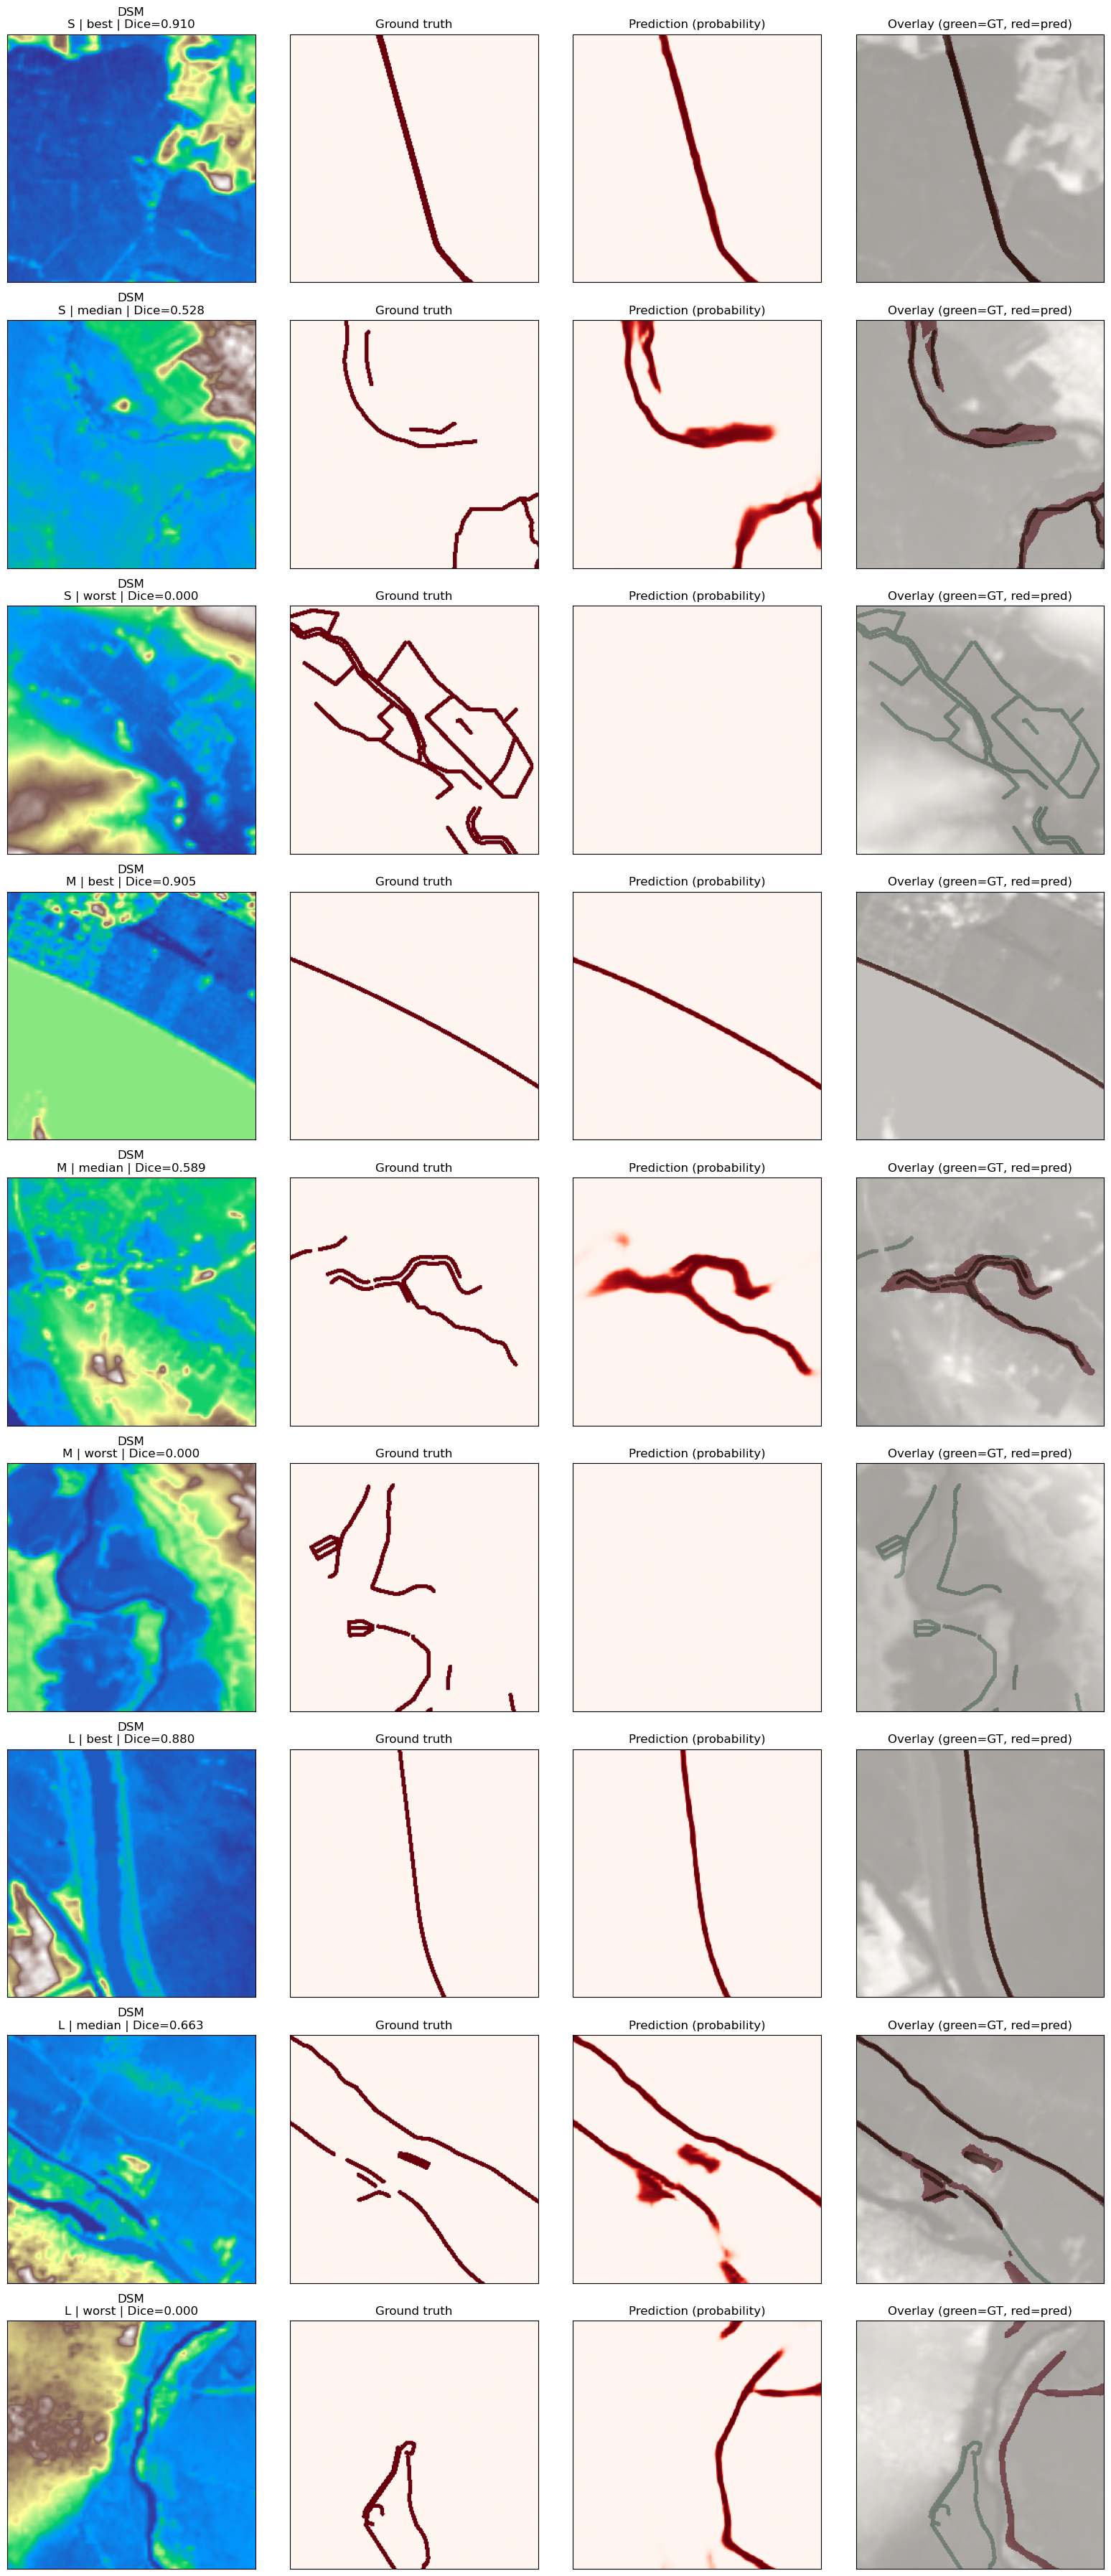

In [ ]:

# Pick samples to visualize: best, worst, and median patches per category
N_PER_CATEGORY = 3   # show top, bottom, median

selected_patches = []
for cat in ["S", "M", "L"]:
    cat_results = test_results[
        (test_results["category"] == cat) &
        (test_results["patch_type"] == "positive")
    ].sort_values("dice", ascending=False)

    if len(cat_results) == 0:
        continue

    n = len(cat_results)
    indices = [0, n // 2, n - 1][:min(N_PER_CATEGORY, n)]
    for label, idx in zip(["best", "median", "worst"], indices):
        selected_patches.append({
            "patch_id": cat_results.iloc[idx]["patch_id"],
            "category": cat,
            "rank":     label,
            "dice":     cat_results.iloc[idx]["dice"],
        })

# Plot grid: rows = patches, cols = DSM, label, prediction, overlay
n_rows = len(selected_patches)
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows), squeeze=False)

with torch.no_grad():
    for row, sample in enumerate(selected_patches):
        # Find index in test_ds
        df_idx = df_test[df_test["patch_id"] == sample["patch_id"]].index[0]
        item = test_ds[df_idx]

        image = item["image"].unsqueeze(0).to(DEVICE)
        label = item["label"].numpy()[0]

        with autocast(enabled=MIXED_PRECISION):
            pred = model(image)
            pred_prob = torch.sigmoid(pred).cpu().numpy()[0, 0]

        # Reload raw DSM for display (un-normalized)
        npz_path = patches_root_dirs[df_test.iloc[df_idx]["region"]] / f"{sample['patch_id']}.npz"
        raw = dict(np.load(npz_path))
        dsm_raw = raw["dsm"]

        ax_dsm, ax_label, ax_pred, ax_overlay = axes[row]

        ax_dsm.imshow(dsm_raw, cmap="terrain")
        ax_dsm.set_title(f"DSM\n{sample['category']} | {sample['rank']} | Dice={sample['dice']:.3f}")

        ax_label.imshow(label, cmap="Reds", vmin=0, vmax=1)
        ax_label.set_title("Ground truth")

        ax_pred.imshow(pred_prob, cmap="Reds", vmin=0, vmax=1)
        ax_pred.set_title("Prediction (probability)")

        ax_overlay.imshow(dsm_raw, cmap="gray")
        ax_overlay.imshow(label, cmap="Greens", alpha=0.4, vmin=0, vmax=1)
        ax_overlay.imshow(pred_prob > 0.5, cmap="Reds", alpha=0.4, vmin=0, vmax=1)
        ax_overlay.set_title("Overlay (green=GT, red=pred)")

        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictions_visualization.png", dpi=120, bbox_inches="tight")
plt.show()